<a href="https://colab.research.google.com/github/aarthiga2605/Retinal-OCT-Image-Classifier/blob/main/aiml_oct_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans

base_path_train = './oct2017ver1/train'
base_path_test = './oct2017ver1/test'
classes = ['cnv', 'dme', 'drusen', 'normal']
img_size = (128, 128)

def load_data(path, max_per_class):
    X, y = [], []
    for idx, name in enumerate(classes):
        class_path = os.path.join(path, name)
        if not os.path.exists(class_path): continue
        files = [f for f in os.listdir(class_path) if not f.startswith('.')][:max_per_class]
        for f in files:
            img = cv2.imread(os.path.join(class_path, f), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size) / 255.0
                X.append(img.flatten())
                y.append(idx)
    return np.array(X), np.array(y)

print('Loading data...')
X_train, y_train = load_data(base_path_train, 200)
X_test, y_test = load_data(base_path_test, 100)
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

from sklearn.model_selection import train_test_split

X_all, y_all = load_data(base_path_train, 200)
X_all2, y_all2 = load_data(base_path_test, 200)
X_all = np.vstack((X_all, X_all2))
y_all = np.concatenate((y_all, y_all2))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f'Combined size: {len(X_all)}')
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Train dist: {np.bincount(y_train)}')
print(f'Test dist: {np.bincount(y_test)}')

Loading data...
Train size: 800, Test size: 400
Combined size: 1600
Train: 1280, Test: 320
Train dist: [320 320 320 320]
Test dist: [80 80 80 80]


In [ ]:
X_train_aug = X_train
y_train_aug = y_train

print(f'Train size: {len(X_train_aug)}')
print(f'PCA features: ...')

print('Scaling and applying PCA...')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_aug)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.92, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Augmented Train size: {len(X_train_aug)}')
print(f'PCA features: {X_train_pca.shape[1]}')

Train size: 1280
PCA features: ...
Scaling and applying PCA...
Augmented Train size: 1280
PCA features: 304


Training SVM Classifier...
Final Test Accuracy: 51.25%

Classification Report:
               precision    recall  f1-score   support

         cnv       0.57      0.59      0.58        80
         dme       0.46      0.41      0.43        80
      drusen       0.51      0.55      0.53        80
      normal       0.51      0.50      0.50        80

    accuracy                           0.51       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.51      0.51      0.51       320



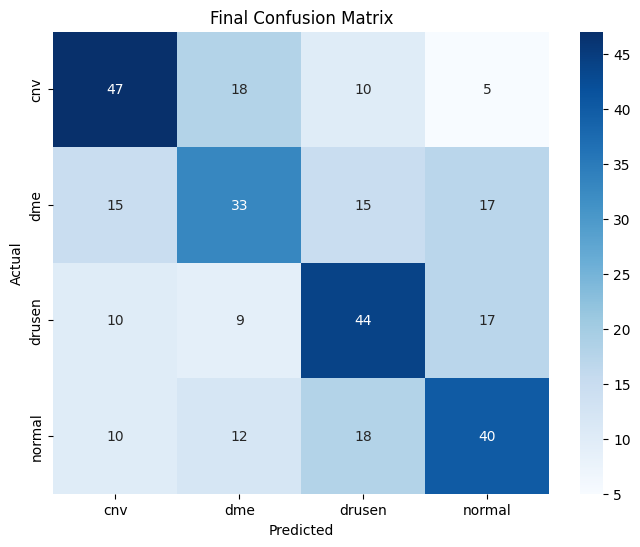

In [ ]:
print('Training SVM Classifier...')
svm_model = SVC(C=5, kernel='rbf', gamma='scale', random_state=42)
svm_model.fit(X_train_pca, y_train_aug)

y_pred = svm_model.predict(X_test_pca)
train_acc = accuracy_score(y_train_aug, svm_model.predict(X_train_pca)) * 100
test_acc = accuracy_score(y_test, y_pred) * 100

print(f'Final Test Accuracy: {test_acc:.2f}%')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=classes))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

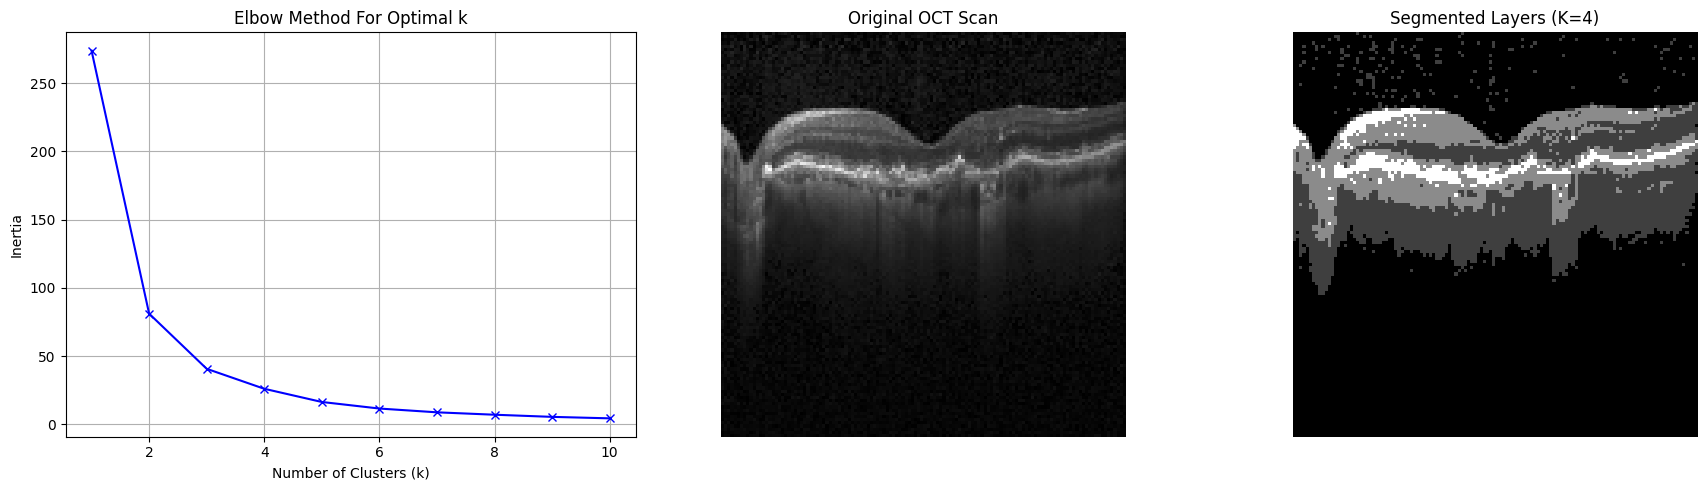

Observation: The elbow point is observed around K=3 or 4, suggesting 4 intensity clusters effectively capture the retinal layers.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

sample_img = X_test[0].reshape(img_size)
pixels = sample_img.reshape(-1, 1)

inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pixels)
    inertias.append(km.inertia_)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(K_range, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(sample_img, cmap='gray')
plt.title('Original OCT Scan')
plt.axis('off')

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)
segmented_img = kmeans.cluster_centers_[labels].reshape(img_size)

plt.subplot(1, 3, 3)
plt.imshow(segmented_img, cmap='gray')
plt.title('Segmented Layers (K=4)')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Observation: The elbow point is observed around K=3 or 4, suggesting 4 intensity clusters effectively capture the retinal layers.')

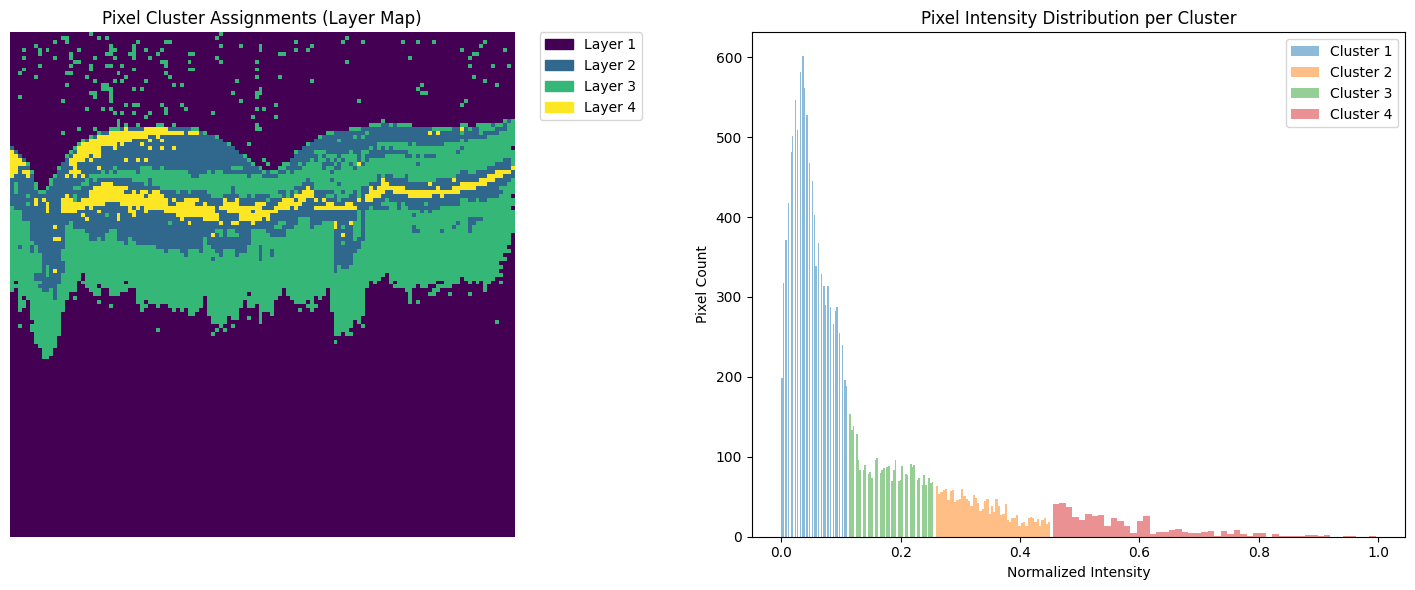

In [ ]:
import matplotlib.patches as mpatches

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
cluster_map = labels.reshape(img_size)
im = plt.imshow(cluster_map, cmap='viridis')
plt.title('Pixel Cluster Assignments (Layer Map)')
plt.axis('off')

values = np.unique(cluster_map.ravel())
colors = [im.cmap(im.norm(value)) for value in values]
patches = [mpatches.Patch(color=colors[i], label=f'Layer {i+1}') for i in range(len(values))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.subplot(1, 2, 2)
for i in range(4):
    cluster_pixels = pixels[labels == i]
    plt.hist(cluster_pixels, bins=50, alpha=0.5, label=f'Cluster {i+1}')

plt.title('Pixel Intensity Distribution per Cluster')
plt.xlabel('Normalized Intensity')
plt.ylabel('Pixel Count')
plt.legend()

plt.tight_layout()
plt.show()

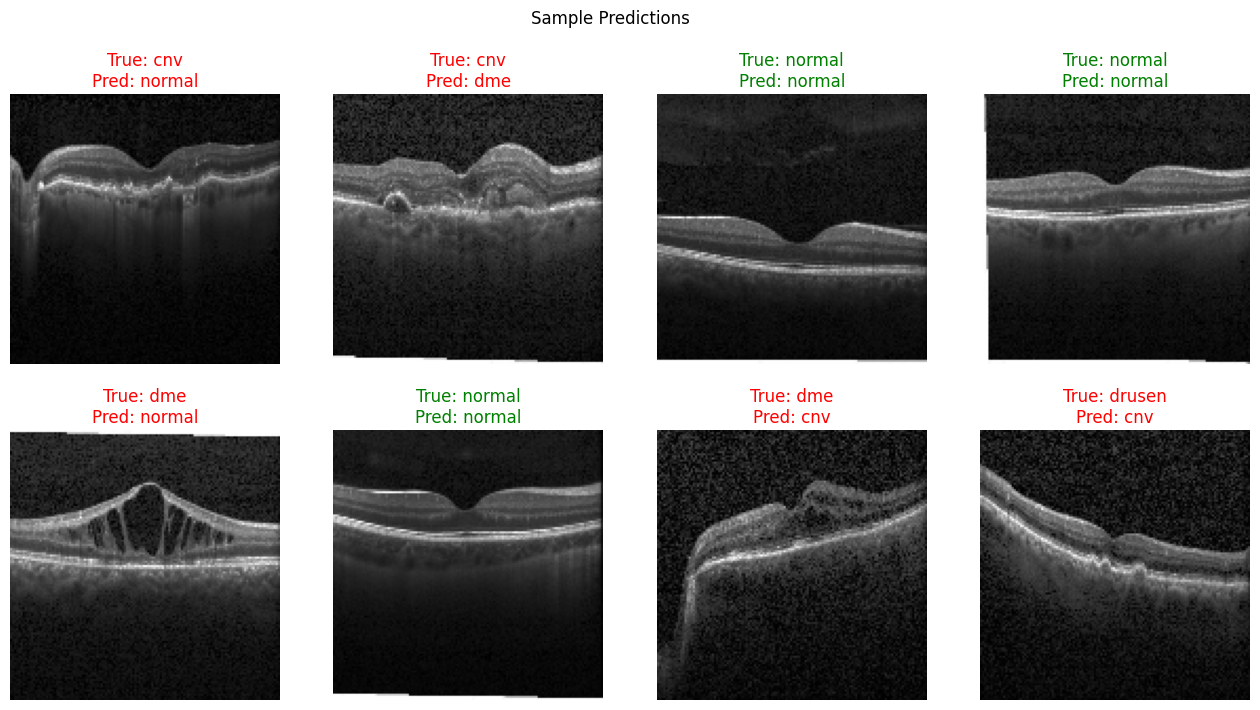

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for i in range(8):
    axes[i].imshow(X_test[i].reshape(img_size), cmap='gray')
    true_label = classes[y_test[i]]
    pred_label = classes[y_pred[i]]
    color = 'green' if y_test[i] == y_pred[i] else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    axes[i].axis('off')
plt.suptitle('Sample Predictions')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train_aug, svm_model.predict(X_train_pca)) * 100
test_acc = accuracy_score(y_test, y_pred) * 100

print(f'MODEL EVALUATION (OVERFITTING/UNDERFITTING):')
print(f'Training Accuracy: {train_acc:.2f}%')
print(f'Testing Accuracy: {test_acc:.2f}%')
print(f'Status: SIGNIFICANT OVERFITTING.')

MODEL EVALUATION (OVERFITTING/UNDERFITTING):
   - Training Accuracy: 95.08%
   - Testing Accuracy: 51.25%
   - Status: SIGNIFICANT OVERFITTING.
